# 🔁 Notebook 07 — Walk-Forward CV Builder

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">🔁 Walk-Forward CV Builder</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase A — Fondasi Data dan Eksperimen</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 07 membangun **walk-forward cross validation** dari setiap *train set* hasil Notebook 06 dengan skema **expanding window** dan **`k = 5` fold**. Seluruh fold disusun tetap kronologis agar validasi temporal konsisten dengan karakter data *time series*.

> ⚠️ **Anti-Leakage:** Fold validasi selalu berada **setelah** data train pada setiap iterasi. Tidak ada shuffle, tidak ada overlap train-validation dalam fold yang sama, dan tidak ada data test Notebook 06 yang ikut ke proses CV.

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | **Import & Setup** | Muat library, seed, PATHS, dan parameter `k = 5` |
| 2 | **Load Split Artifacts** | Load `split_60_40.npz` s.d. `split_90_10.npz` |
| 3 | **Build Walk-Forward Folds** | Bentuk fold expanding window untuk tiap split |
| 4 | **Validasi Integritas** | Cek urutan temporal, ukuran fold, dan leakage |
| 5 | **Visualisasi Fold** | Plot blok train-validation untuk seluruh split |
| 6 | **Simpan Artefak** | `.npz` per split + ringkasan JSON + figur |
| 7 | **Checklist** | Verifikasi semua item Pipeline.md Gate terpenuhi |

---

### 🔬 Konsep Walk-Forward CV

Untuk setiap split dengan jumlah data train $n_{train}$ dan jumlah fold $k = 5$, ukuran blok validasi ditetapkan:
$$n_{val} = \left\lfloor \frac{n_{train}}{k + 1} \right\rfloor$$

Sisa data train awal dipakai sebagai *initial train window*:
$$n_{init} = n_{train} - k \cdot n_{val}$$

Pada fold ke-$i$, data train terus **bertambah** (*expanding*) dan blok validasi bergerak maju satu segmen:
- Train fold-$i$: indeks $[0,\; n_{init} + i \cdot n_{val})$
- Validation fold-$i$: indeks $[n_{init} + i \cdot n_{val},\; n_{init} + (i+1) \cdot n_{val})$

**Alur Proses:**

```mermaid
flowchart LR
    A["Split artifacts<br/>split_*.npz"] --> B["Load X_train dan y_train<br/>tiap rasio"]
    B --> C["Build Walk-Forward CV<br/>k=5 · expanding window"]
    C --> D["Validasi integritas<br/>temporal · overlap · coverage"]
    D --> E["Visualisasi timeline fold"]
    E --> F["Simpan artefak CV<br/>outputs/cv_folds/wf_cv_*.npz"]
    F --> G["Simpan ringkasan<br/>logs/walk_forward_summary.json"]
    G --> H["Lanjut ke NB08<br/>CNN Baseline All Splits"]
```

| Aspek | Detail |
|-------|--------|
| **Input** | `split_*.npz` dari Notebook 06 |
| **Jumlah Fold** | 5 fold untuk setiap rasio split |
| **Strategi** | *Walk-forward CV* dengan *expanding window* |
| **Objek yang Divalidasi** | Ukuran train/validation, urutan indeks, dan non-overlap |
| **Artefak Output** | `outputs/cv_folds/wf_cv_*.npz`, `logs/walk_forward_summary.json`, `outputs/figures/nb07_walk_forward_overview.png` |

## ⚙️ 1. Import Library & Setup

In [1]:
# ── Import Library & Setup ────────────────────────────────────
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── Path Konfigurasi ──────────────────────────────────────────
ROOT_DIR = Path(".").resolve().parent

PATHS = {
    "root"        : ROOT_DIR,
    "data"        : ROOT_DIR / "data",
    "logs"        : ROOT_DIR / "logs",
    "outputs"     : ROOT_DIR / "outputs",
    "figures"     : ROOT_DIR / "outputs" / "figures",
    "models"      : ROOT_DIR / "outputs" / "models",
    "metrics"     : ROOT_DIR / "outputs" / "metrics",
    "splits"      : ROOT_DIR / "outputs" / "splits",
    "cv_folds"    : ROOT_DIR / "outputs" / "cv_folds",
    "checkpoints" : ROOT_DIR / "outputs" / "checkpoints",
    "reports"     : ROOT_DIR / "outputs" / "reports",
    "assets"      : ROOT_DIR / "outputs" / "assets",
    "notebooks"   : ROOT_DIR / "notebook",
}

for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

SPLIT_RATIOS = [
    ("60:40", 0.60),
    ("70:30", 0.70),
    ("80:20", 0.80),
    ("90:10", 0.90),
]

K_FOLDS = 5
TAU = 8

# ── Matplotlib Style ─────────────────────────────────────────
ACCENT  = "#e94560"
ACCENT2 = "#a8dadc"

plt.rcParams.update({
    "figure.facecolor"  : "#1a1a2e",
    "axes.facecolor"    : "#16213e",
    "axes.edgecolor"    : "#444",
    "axes.labelcolor"   : "#ccc",
    "xtick.color"       : "#aaa",
    "ytick.color"       : "#aaa",
    "text.color"        : "#ddd",
    "grid.color"        : "#2a2a4a",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.5,
    "axes.grid"         : True,
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

print("=" * 60)
print("  SETUP — NOTEBOOK 07")
print("=" * 60)
print()
print(f"  GLOBAL_SEED   : {GLOBAL_SEED}")
print(f"  ROOT_DIR      : {ROOT_DIR}")
print(f"  K_FOLDS       : {K_FOLDS}")
print(f"  TAU           : {TAU}")
print(f"  Rasio split   : {[r for r, _ in SPLIT_RATIOS]}")
print(f"  NumPy         : {np.__version__}")
print(f"  Pandas        : {pd.__version__}")
print(f"  Matplotlib    : {matplotlib.__version__}")
print(f"  Seaborn       : {sns.__version__}")
print()
print("  ✅ Setup selesai. Siap Walk-Forward CV Builder.")
print("=" * 60)

  SETUP — NOTEBOOK 07

  GLOBAL_SEED   : 42
  ROOT_DIR      : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting
  K_FOLDS       : 5
  TAU           : 8
  Rasio split   : ['60:40', '70:30', '80:20', '90:10']
  NumPy         : 2.4.4
  Pandas        : 3.0.2
  Matplotlib    : 3.10.9
  Seaborn       : 0.13.2

  ✅ Setup selesai. Siap Walk-Forward CV Builder.


## 📂 2. Load Split Artifacts (`split_*.npz`)

In [2]:
# ── Load split artifacts dari Notebook 06 ───────────────────
split_artifacts = {}
split_overview_rows = []

for label, ratio in SPLIT_RATIOS:
    file_name = f"split_{label.replace(':', '_')}.npz"
    split_path = PATHS["splits"] / file_name
    if not split_path.exists():
        raise FileNotFoundError(
            f"❌ Artefak {file_name} tidak ditemukan. Jalankan Notebook 06 terlebih dahulu!"
        )

    data = np.load(split_path, allow_pickle=True)
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]

    split_artifacts[label] = {
        "ratio"     : ratio,
        "path"      : split_path,
        "X_train"   : X_train,
        "y_train"   : y_train,
        "X_test"    : X_test,
        "y_test"    : y_test,
        "n_train"   : len(y_train),
        "n_test"    : len(y_test),
        "n_total"   : len(y_train) + len(y_test),
    }

    split_overview_rows.append({
        "split"       : label,
        "train_ratio" : ratio,
        "n_total"     : len(y_train) + len(y_test),
        "n_train"     : len(y_train),
        "n_test"      : len(y_test),
        "X_train"     : str(X_train.shape),
        "X_test"      : str(X_test.shape),
    })

split_df = pd.DataFrame(split_overview_rows)
display(split_df)

print("=" * 72)
print("  LOAD SPLIT ARTIFACTS — NOTEBOOK 07")
print("=" * 72)
for row in split_overview_rows:
    print(
        f"  {row['split']:<8} | train={row['n_train']:>3} | test={row['n_test']:>3} "
        f"| X_train={row['X_train']:<10} | X_test={row['X_test']}"
    )
print("=" * 72)
print("  ✅ Seluruh split Notebook 06 berhasil dimuat.")
print("=" * 72)

,split,train_ratio,n_total,n_train,n_test,X_train,X_test
0,60:40,0.6,356,213,143,"(213, 8)","(143, 8)"
1,70:30,0.7,356,249,107,"(249, 8)","(107, 8)"
2,80:20,0.8,356,284,72,"(284, 8)","(72, 8)"
3,90:10,0.9,356,320,36,"(320, 8)","(36, 8)"


  LOAD SPLIT ARTIFACTS — NOTEBOOK 07
  60:40    | train=213 | test=143 | X_train=(213, 8)   | X_test=(143, 8)
  70:30    | train=249 | test=107 | X_train=(249, 8)   | X_test=(107, 8)
  80:20    | train=284 | test= 72 | X_train=(284, 8)   | X_test=(72, 8)
  90:10    | train=320 | test= 36 | X_train=(320, 8)   | X_test=(36, 8)
  ✅ Seluruh split Notebook 06 berhasil dimuat.


## 🔁 3. Build Walk-Forward CV (Expanding Window)

In [3]:
# ── Builder walk-forward CV ──────────────────────────────────
def build_walk_forward_folds(X_train, y_train, split_label, k_folds=5):
    n_train = len(y_train)
    val_size = n_train // (k_folds + 1)
    initial_train_size = n_train - (k_folds * val_size)

    if val_size <= 0:
        raise ValueError(
            f"❌ Split {split_label} terlalu kecil untuk k={k_folds} fold."
        )
    if initial_train_size <= 0:
        raise ValueError(
            f"❌ Initial train window split {split_label} tidak valid: {initial_train_size}"
        )

    folds = []
    train_end_indices = []
    val_start_indices = []
    val_end_indices = []

    for fold_idx in range(k_folds):
        train_end = initial_train_size + (fold_idx * val_size)
        val_start = train_end
        val_end = val_start + val_size

        train_idx = np.arange(0, train_end, dtype=int)
        val_idx = np.arange(val_start, val_end, dtype=int)

        folds.append({
            "fold"         : fold_idx + 1,
            "train_idx"    : train_idx,
            "val_idx"      : val_idx,
            "X_train_fold" : X_train[train_idx],
            "y_train_fold" : y_train[train_idx],
            "X_val_fold"   : X_train[val_idx],
            "y_val_fold"   : y_train[val_idx],
        })

        train_end_indices.append(train_end)
        val_start_indices.append(val_start)
        val_end_indices.append(val_end)

    return {
        "split_label"         : split_label,
        "n_train_total"       : n_train,
        "k_folds"             : k_folds,
        "val_size"            : val_size,
        "initial_train_size"  : initial_train_size,
        "folds"               : folds,
        "train_end_indices"   : np.array(train_end_indices, dtype=int),
        "val_start_indices"   : np.array(val_start_indices, dtype=int),
        "val_end_indices"     : np.array(val_end_indices, dtype=int),
    }

cv_registry = {}
fold_rows = []

for label, artifact in split_artifacts.items():
    cv_bundle = build_walk_forward_folds(
        X_train=artifact['X_train'],
        y_train=artifact['y_train'],
        split_label=label,
        k_folds=K_FOLDS,
    )
    cv_registry[label] = cv_bundle

    for fold in cv_bundle['folds']:
        fold_rows.append({
            "split"        : label,
            "fold"         : fold['fold'],
            "train_size"   : len(fold['train_idx']),
            "val_size"     : len(fold['val_idx']),
            "train_end"    : int(fold['train_idx'][-1]) if len(fold['train_idx']) else -1,
            "val_start"    : int(fold['val_idx'][0]),
            "val_end"      : int(fold['val_idx'][-1]),
        })

fold_df = pd.DataFrame(fold_rows)
display(fold_df)

print("=" * 76)
print("  WALK-FORWARD CV BUILDER — RINGKASAN FOLD")
print("=" * 76)
for label, bundle in cv_registry.items():
    print(
        f"  {label:<8} | n_train={bundle['n_train_total']:>3} | initial={bundle['initial_train_size']:>3} "
        f"| val_size={bundle['val_size']:>3} | folds={bundle['k_folds']}"
    )
print("=" * 76)
print("  ✅ Walk-forward fold berhasil dibentuk untuk seluruh split.")
print("=" * 76)

,split,fold,train_size,val_size,train_end,val_start,val_end
0,60:40,1,38,35,37,38,72
1,60:40,2,73,35,72,73,107
2,60:40,3,108,35,107,108,142
3,60:40,4,143,35,142,143,177
4,60:40,5,178,35,177,178,212
5,70:30,1,44,41,43,44,84
6,70:30,2,85,41,84,85,125
7,70:30,3,126,41,125,126,166
8,70:30,4,167,41,166,167,207
9,70:30,5,208,41,207,208,248


  WALK-FORWARD CV BUILDER — RINGKASAN FOLD
  60:40    | n_train=213 | initial= 38 | val_size= 35 | folds=5
  70:30    | n_train=249 | initial= 44 | val_size= 41 | folds=5
  80:20    | n_train=284 | initial= 49 | val_size= 47 | folds=5
  90:10    | n_train=320 | initial= 55 | val_size= 53 | folds=5
  ✅ Walk-forward fold berhasil dibentuk untuk seluruh split.


## 🔍 4. Validasi Integritas & Visualisasi Fold

,split,n_train_total,initial_train_size,val_size,temporal_ok,no_leakage_ok,coverage_ok
0,60:40,213,38,35,True,True,True
1,70:30,249,44,41,True,True,True
2,80:20,284,49,47,True,True,True
3,90:10,320,55,53,True,True,True


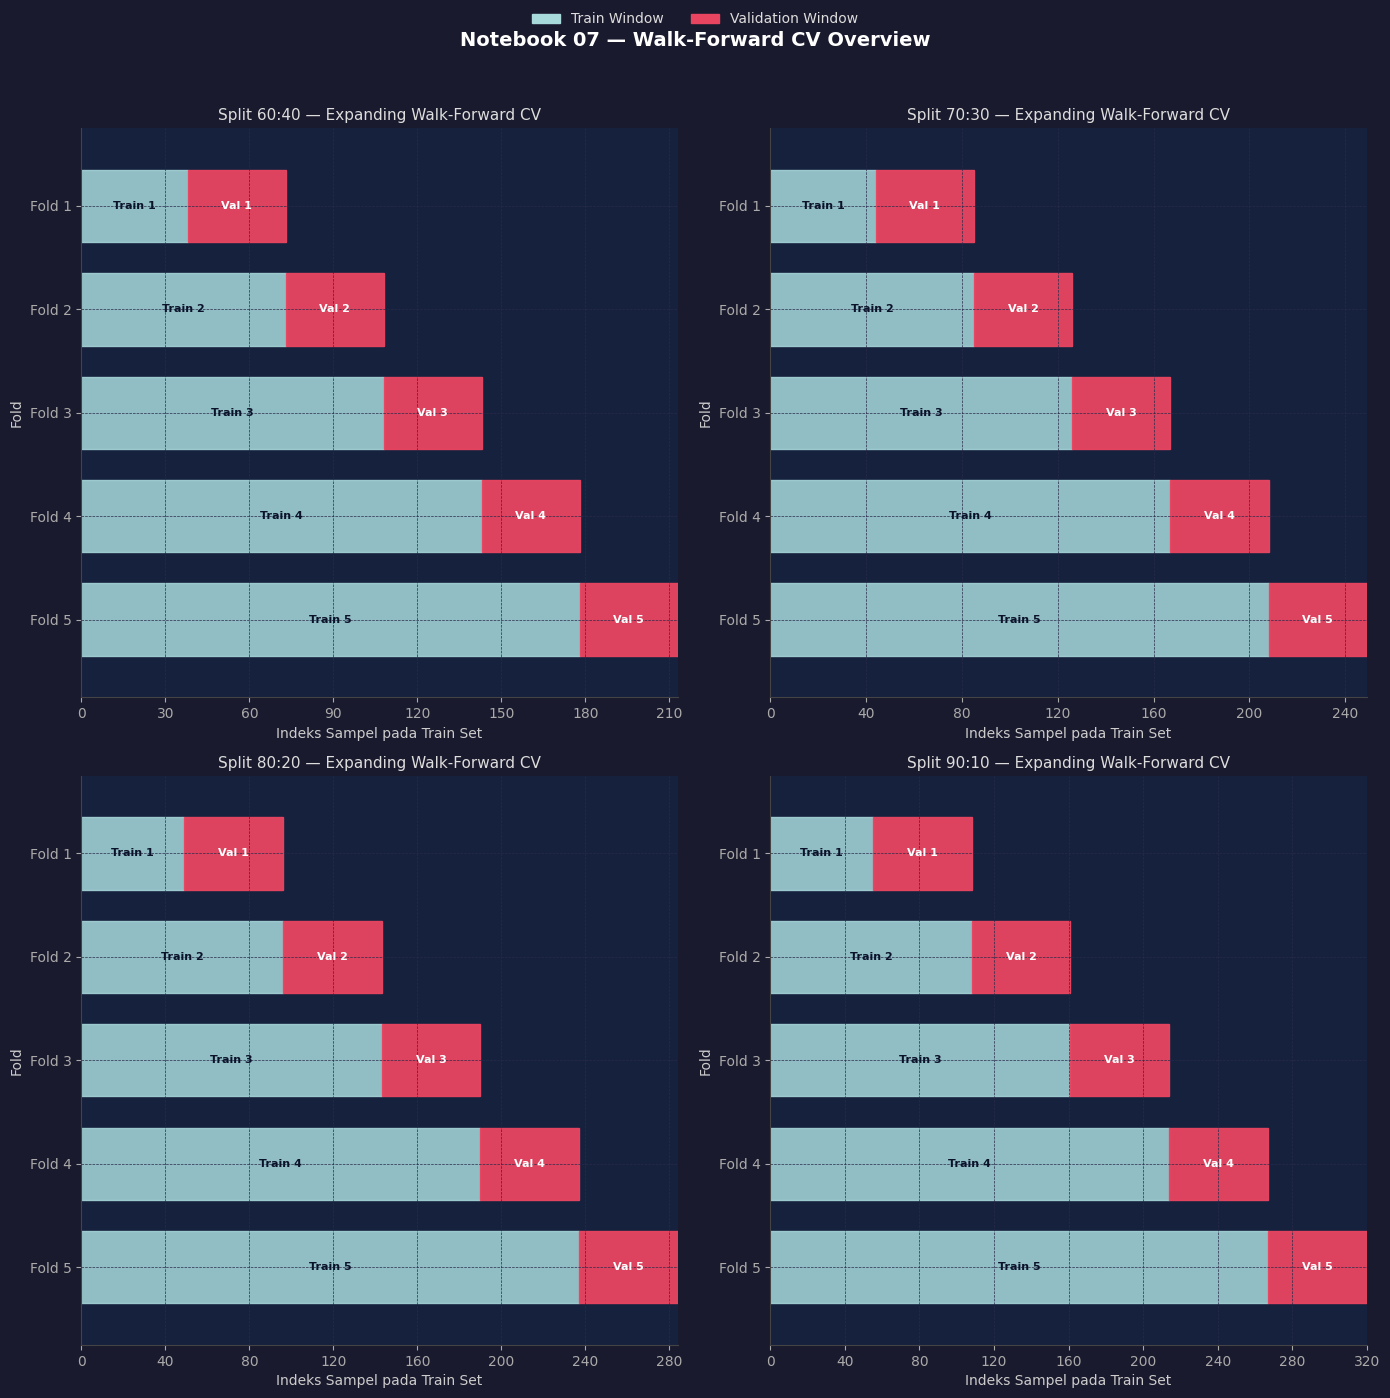

  VALIDASI INTEGRITAS TEMPORAL — NOTEBOOK 07
  ✅ Temporal ordering  : True
  ✅ Tidak ada leakage  : True
  ✅ Coverage fold valid: True
  ✅ Figur tersimpan    : nb07_walk_forward_overview.png


In [4]:
# ── Validasi integritas fold ─────────────────────────────────
validation_rows = []
all_temporal_ok = True
all_leakage_ok = True
all_coverage_ok = True

for label, bundle in cv_registry.items():
    n_train_total = bundle['n_train_total']
    used_val_indices = []

    split_temporal_ok = True
    split_leakage_ok = True
    split_coverage_ok = True

    for fold in bundle['folds']:
        train_idx = fold['train_idx']
        val_idx = fold['val_idx']

        temporal_ok = (
            len(train_idx) > 0
            and len(val_idx) > 0
            and train_idx[-1] < val_idx[0]
            and np.all(np.diff(train_idx) == 1)
            and np.all(np.diff(val_idx) == 1)
        )
        leakage_ok = len(np.intersect1d(train_idx, val_idx)) == 0

        if not temporal_ok:
            split_temporal_ok = False
            all_temporal_ok = False
        if not leakage_ok:
            split_leakage_ok = False
            all_leakage_ok = False

        used_val_indices.extend(val_idx.tolist())

    coverage_ok = (
        min(used_val_indices) == bundle['initial_train_size']
        and max(used_val_indices) == n_train_total - 1
        and len(used_val_indices) == bundle['val_size'] * bundle['k_folds']
        and len(np.unique(used_val_indices)) == len(used_val_indices)
    )

    if not coverage_ok:
        split_coverage_ok = False
        all_coverage_ok = False

    validation_rows.append({
        "split"             : label,
        "n_train_total"     : n_train_total,
        "initial_train_size": bundle['initial_train_size'],
        "val_size"          : bundle['val_size'],
        "temporal_ok"       : split_temporal_ok,
        "no_leakage_ok"     : split_leakage_ok,
        "coverage_ok"       : split_coverage_ok,
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

# ── Visualisasi fold timeline ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 14), facecolor='#1a1a2e')
axes = axes.flatten()

for ax, (label, bundle) in zip(axes, cv_registry.items()):
    ax.set_facecolor('#16213e')

    for fold in bundle['folds']:
        row_y = bundle['k_folds'] - fold['fold']
        train_start = 0
        train_width = len(fold['train_idx'])
        val_start = int(fold['val_idx'][0])
        val_width = len(fold['val_idx'])

        ax.add_patch(
            mpatches.Rectangle((train_start, row_y - 0.35), train_width, 0.7,
                               color=ACCENT2, alpha=0.85)
        )
        ax.add_patch(
            mpatches.Rectangle((val_start, row_y - 0.35), val_width, 0.7,
                               color=ACCENT, alpha=0.95)
        )
        ax.text(train_width / 2, row_y, f"Train {fold['fold']}",
                color='#0b132b', ha='center', va='center', fontsize=8, fontweight='bold')
        ax.text(val_start + (val_width / 2), row_y, f"Val {fold['fold']}",
                color='white', ha='center', va='center', fontsize=8, fontweight='bold')

    ax.set_xlim(0, bundle['n_train_total'])
    ax.set_ylim(-0.75, bundle['k_folds'] - 0.25)
    ax.set_title(
        f"Split {label} — Expanding Walk-Forward CV",
        color='#ddd', fontsize=11
    )
    ax.set_xlabel('Indeks Sampel pada Train Set', color='#ccc')
    ax.set_ylabel('Fold', color='#ccc')
    ax.set_yticks(range(bundle['k_folds']))
    ax.set_yticklabels([f"Fold {i}" for i in range(bundle['k_folds'], 0, -1)])
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    for spine in ax.spines.values():
        spine.set_color('#444')

legend_handles = [
    mpatches.Patch(color=ACCENT2, label='Train Window'),
    mpatches.Patch(color=ACCENT, label='Validation Window'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, fontsize=10)
fig.suptitle('Notebook 07 — Walk-Forward CV Overview', color='white', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])

figure_path = PATHS['figures'] / 'nb07_walk_forward_overview.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("=" * 64)
print("  VALIDASI INTEGRITAS TEMPORAL — NOTEBOOK 07")
print("=" * 64)
print(f"  ✅ Temporal ordering  : {all_temporal_ok}")
print(f"  ✅ Tidak ada leakage  : {all_leakage_ok}")
print(f"  ✅ Coverage fold valid: {all_coverage_ok}")
print(f"  ✅ Figur tersimpan    : {figure_path.name}")
print("=" * 64)

## 💾 5. Simpan Artefak Fold CV

In [5]:
# ── Simpan artefak fold CV ───────────────────────────────────
summary_payload = {
    "notebook" : "07 - Walk-Forward CV Builder",
    "timestamp": __import__('datetime').datetime.now().isoformat(timespec='seconds'),
    "k_folds"  : K_FOLDS,
    "strategy" : "walk-forward-expanding-window",
    "splits"   : {},
}

for label, bundle in cv_registry.items():
    save_path = PATHS['cv_folds'] / f"wf_cv_{label.replace(':', '_')}.npz"

    fold_train_sizes = np.array([len(f['train_idx']) for f in bundle['folds']], dtype=int)
    fold_val_sizes   = np.array([len(f['val_idx']) for f in bundle['folds']], dtype=int)

    np.savez(
        save_path,
        split_label=np.array(label),
        k_folds=np.array(bundle['k_folds']),
        n_train_total=np.array(bundle['n_train_total']),
        initial_train_size=np.array(bundle['initial_train_size']),
        val_size=np.array(bundle['val_size']),
        train_end_indices=bundle['train_end_indices'],
        val_start_indices=bundle['val_start_indices'],
        val_end_indices=bundle['val_end_indices'],
        fold_train_sizes=fold_train_sizes,
        fold_val_sizes=fold_val_sizes,
    )

    summary_payload['splits'][label] = {
        "source_split"        : str(split_artifacts[label]['path'].relative_to(ROOT_DIR)),
        "saved_cv_artifact"   : str(save_path.relative_to(ROOT_DIR)),
        "n_train_total"       : int(bundle['n_train_total']),
        "initial_train_size"  : int(bundle['initial_train_size']),
        "val_size"            : int(bundle['val_size']),
        "k_folds"             : int(bundle['k_folds']),
        "folds"               : [
            {
                "fold"       : int(f['fold']),
                "train_size" : int(len(f['train_idx'])),
                "val_size"   : int(len(f['val_idx'])),
                "train_end"  : int(f['train_idx'][-1]),
                "val_start"  : int(f['val_idx'][0]),
                "val_end"    : int(f['val_idx'][-1]),
            }
            for f in bundle['folds']
        ],
    }

summary_path = PATHS['logs'] / 'walk_forward_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

with open(summary_path, 'r', encoding='utf-8') as f:
    rt_json = json.load(f)

saved_files = sorted([p.name for p in PATHS['cv_folds'].glob('wf_cv_*.npz')])

print("=" * 70)
print("  SIMPAN ARTEFAK WALK-FORWARD CV")
print("=" * 70)
for file_name in saved_files:
    print(f"  ✅ {file_name}")
print(f"  ✅ {summary_path.name}")
print(f"  ✅ {figure_path.name}")
print("=" * 70)
print(f"  Total artefak split tersimpan : {len(saved_files)} file .npz")
print("=" * 70)

  SIMPAN ARTEFAK WALK-FORWARD CV
  ✅ wf_cv_60_40.npz
  ✅ wf_cv_70_30.npz
  ✅ wf_cv_80_20.npz
  ✅ wf_cv_90_10.npz
  ✅ walk_forward_summary.json
  ✅ nb07_walk_forward_overview.png
  Total artefak split tersimpan : 4 file .npz


## ✅ 6. Checklist Akhir Notebook 07

In [6]:
# ── Checklist akhir Notebook 07 ──────────────────────────────
fold_files_exist = all(
    (PATHS['cv_folds'] / f"wf_cv_{label.replace(':', '_')}.npz").exists()
    for label in cv_registry.keys()
)
summary_exists = summary_path.exists()
figure_exists = figure_path.exists()

fold_count_ok = all(bundle['k_folds'] == K_FOLDS for bundle in cv_registry.values())
temporal_ok = all(validation_df['temporal_ok'])
no_leakage_ok = all(validation_df['no_leakage_ok'])
coverage_ok = all(validation_df['coverage_ok'])
summary_ok = (summary_exists and figure_exists and len(rt_json['splits']) == 4 and fold_files_exist)

checklist = [
    ("Fold CV tiap split terbentuk", fold_count_ok and fold_files_exist),
    ("Urutan temporal terjaga", temporal_ok and coverage_ok),
    ("Tidak ada fold leakage", no_leakage_ok),
    ("Ringkasan JSON dan figur tersimpan", summary_ok),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 07")
print("=" * 60)
all_pass = True
for label, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"  {icon}  {label}")
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 07 selesai!")
    print("     Lanjutkan ke Notebook 08 — CNN Baseline All Splits.")
else:
    print("  ❌ Ada checklist yang GAGAL — periksa log di atas.")
print("=" * 60)

  CHECKLIST NOTEBOOK 07
  ✅  Fold CV tiap split terbentuk
  ✅  Urutan temporal terjaga
  ✅  Tidak ada fold leakage
  ✅  Ringkasan JSON dan figur tersimpan
  ✅ SEMUA CHECKLIST LULUS — Notebook 07 selesai!
     Lanjutkan ke Notebook 08 — CNN Baseline All Splits.


---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[06 - Split Builder for All Ratios](./06%20-%20Split%20Builder%20for%20All%20Ratios.ipynb)** |
| **→** | **[08 - CNN Baseline All Splits](./08%20-%20CNN%20Baseline%20All%20Splits.ipynb)** |

---

### 📎 Variabel Penting yang Dihasilkan Notebook Ini

Variabel berikut tersedia untuk notebook selanjutnya (dimuat ulang dari file atau dihitung kembali):

```python
cv_registry          # dict — bundle walk-forward CV tiap rasio split
fold_df              # pd.DataFrame — ringkasan fold (train_size, val_size, indices)
validation_df        # pd.DataFrame — hasil validasi integritas temporal & leakage
PATHS                # dict path pipeline (sama seperti notebook sebelumnya)

# Artefak tersimpan:
# outputs/cv_folds/wf_cv_60_40.npz
# outputs/cv_folds/wf_cv_70_30.npz
# outputs/cv_folds/wf_cv_80_20.npz
# outputs/cv_folds/wf_cv_90_10.npz
# logs/walk_forward_summary.json
# outputs/figures/nb07_walk_forward_overview.png
```

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 07 — Walk-Forward CV Builder &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>